## Let the Neurons Die Part II - Poisoned Data Construction with the idea of Inverting Gradients Attack

This notebook is an example for reconstructing input training data in a malicious way using weight and gradient information. The reconstructed datapoint(s) will be used for victim model training and the expected outcome should be seeing dead neurons and model never being converged. The model is a custom model with **ReLu** activation function.

### Startup

The startup code should be the same as the *Inverting Gradients Attack*.
Please note that in order to be 100% that we are running the modified `breaching` framework, remember to uninstall the `breaching` library if you installed the package before via `pip3 uninstall breaching`.

In [5]:
try:
    import breaching
except ModuleNotFoundError:
    # You only really need this safety net if you want to run these notebooks directly in the examples directory
    # Don't worry about this if you installed the package or moved the notebook to the main directory.
    import os; os.chdir("..")
    import breaching
    
import torch
import numpy as np
%load_ext autoreload
%autoreload 2

# Redirects logs directly into the jupyter notebook
import logging, sys
logging.basicConfig(level=logging.INFO, handlers=[logging.StreamHandler(sys.stdout)], format='%(message)s')
logger = logging.getLogger()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Investigating use case single_mnist with server type honest_but_curious.


INFO:breaching.cases.users:Computing user update on user 0 in model mode: eval.


[array([[-1.40454825e-02, -2.96367947e-02, -3.73193156e-03, ...,
        -3.65462787e-02, -3.13980095e-02, -3.38774137e-02],
       [-1.27887763e-02, -1.53172892e-02,  2.17504054e-02, ...,
         2.31493711e-02, -2.01520436e-02, -2.02382822e-02],
       [ 1.95875578e-03,  3.46289575e-02,  8.97457357e-03, ...,
        -3.43139432e-02,  1.22368848e-02,  1.85355004e-02],
       ...,
       [-8.33072793e-03,  9.51768085e-03,  1.86587572e-02, ...,
         2.87100747e-02, -2.81406082e-02, -9.47865471e-03],
       [-2.38090269e-02,  2.36297399e-02,  2.84052975e-02, ...,
        -2.00361498e-02,  8.53443562e-05, -1.66687742e-02],
       [-2.55207699e-02,  1.75241344e-02,  2.65778936e-02, ...,
        -3.56049603e-03,  2.96540298e-02,  2.52249800e-02]], dtype=float32), array([[ 0.00133343, -0.03005386, -0.04002051, ..., -0.036305  ,
         0.02381881, -0.04132118],
       [ 0.02489064, -0.00579297,  0.0146622 , ...,  0.00518307,
        -0.03085754,  0.0259238 ],
       [-0.00692874,  0.01

INFO:breaching.attacks.base_attack:Recovered labels [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.5958 |  Task loss: 2.3016 | T: 0.04s
INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.1873 |  Task loss: 2.3015 | T: 4.10s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.1877 |  Task loss: 2.3015 | T: 3.23s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.1882 |  Task loss: 2.3015 | T: 3.02s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.1877 |  Task loss: 2.3015 | T: 2.87s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.1881 |  Task loss: 2.3015 | T: 3.24s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.1874 |  Task loss: 2

[array([[-1.40454825e-02, -2.96367947e-02, -3.73193156e-03, ...,
        -3.65462787e-02, -3.13980095e-02, -3.38774137e-02],
       [-1.27887763e-02, -1.53172892e-02,  2.17504054e-02, ...,
         2.31493711e-02, -2.01520436e-02, -2.02382822e-02],
       [ 1.95875578e-03,  3.46289575e-02,  8.97457357e-03, ...,
        -3.43139432e-02,  1.22368848e-02,  1.85355004e-02],
       ...,
       [-8.33072793e-03,  9.51768085e-03,  1.86587572e-02, ...,
         2.87100747e-02, -2.81406082e-02, -9.47865471e-03],
       [-2.38090269e-02,  2.36297399e-02,  2.84052975e-02, ...,
        -2.00361498e-02,  8.53443562e-05, -1.66687742e-02],
       [-2.55207699e-02,  1.75241344e-02,  2.65778936e-02, ...,
        -3.56049603e-03,  2.96540298e-02,  2.52249800e-02]], dtype=float32), array([[ 0.00133343, -0.03005386, -0.04002051, ..., -0.036305  ,
         0.02381881, -0.04132118],
       [ 0.02489064, -0.00579297,  0.0146622 , ...,  0.00518307,
        -0.03085754,  0.0259238 ],
       [-0.00692874,  0.01

...

INFO:breaching.attacks.base_attack:Recovered labels [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.7150 |  Task loss: 2.3106 | T: 0.00s
INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.2791 |  Task loss: 2.3103 | T: 3.08s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.2877 |  Task loss: 2.3104 | T: 2.83s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.2917 |  Task loss: 2.3104 | T: 3.06s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.2875 |  Task loss: 2.3103 | T: 3.11s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.2881 |  Task loss: 2.3103 | T: 3.09s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.2814 |  Task loss: 2

[array([[-1.40454825e-02, -2.96367947e-02, -3.73193156e-03, ...,
        -3.65462787e-02, -3.13980095e-02, -3.38774137e-02],
       [-1.27887763e-02, -1.53172892e-02,  2.17504054e-02, ...,
         2.31493711e-02, -2.01520436e-02, -2.02382822e-02],
       [ 1.95875578e-03,  3.46289575e-02,  8.97457357e-03, ...,
        -3.43139432e-02,  1.22368848e-02,  1.85355004e-02],
       ...,
       [-8.33072793e-03,  9.51768085e-03,  1.86587572e-02, ...,
         2.87100747e-02, -2.81406082e-02, -9.47865471e-03],
       [-2.38090269e-02,  2.36297399e-02,  2.84052975e-02, ...,
        -2.00361498e-02,  8.53443562e-05, -1.66687742e-02],
       [-2.55207699e-02,  1.75241344e-02,  2.65778936e-02, ...,
        -3.56049603e-03,  2.96540298e-02,  2.52249800e-02]], dtype=float32), array([[ 0.00133343, -0.03005386, -0.04002051, ..., -0.036305  ,
         0.02381881, -0.04132118],
       [ 0.02489064, -0.00579297,  0.0146622 , ...,  0.00518307,
        -0.03085754,  0.0259238 ],
       [-0.00692874,  0.01

INFO:breaching.attacks.base_attack:Recovered labels [8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.5748 |  Task loss: 2.2902 | T: 0.00s
INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.1512 |  Task loss: 2.2904 | T: 3.28s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.1535 |  Task loss: 2.2904 | T: 3.22s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.1526 |  Task loss: 2.2904 | T: 3.20s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.1525 |  Task loss: 2.2904 | T: 3.25s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.1523 |  Task loss: 2.2904 | T: 3.24s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.1520 |  Task loss: 2

[array([[-1.40454825e-02, -2.96367947e-02, -3.73193156e-03, ...,
        -3.65462787e-02, -3.13980095e-02, -3.38774137e-02],
       [-1.27887763e-02, -1.53172892e-02,  2.17504054e-02, ...,
         2.31493711e-02, -2.01520436e-02, -2.02382822e-02],
       [ 1.95875578e-03,  3.46289575e-02,  8.97457357e-03, ...,
        -3.43139432e-02,  1.22368848e-02,  1.85355004e-02],
       ...,
       [-8.33072793e-03,  9.51768085e-03,  1.86587572e-02, ...,
         2.87100747e-02, -2.81406082e-02, -9.47865471e-03],
       [-2.38090269e-02,  2.36297399e-02,  2.84052975e-02, ...,
        -2.00361498e-02,  8.53443562e-05, -1.66687742e-02],
       [-2.55207699e-02,  1.75241344e-02,  2.65778936e-02, ...,
        -3.56049603e-03,  2.96540298e-02,  2.52249800e-02]], dtype=float32), array([[ 0.00133343, -0.03005386, -0.04002051, ..., -0.036305  ,
         0.02381881, -0.04132118],
       [ 0.02489064, -0.00579297,  0.0146622 , ...,  0.00518307,
        -0.03085754,  0.0259238 ],
       [-0.00692874,  0.01

INFO:breaching.attacks.base_attack:Recovered labels [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.7246 |  Task loss: 2.3040 | T: 0.00s
INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.3461 |  Task loss: 2.3028 | T: 3.13s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.3458 |  Task loss: 2.3028 | T: 3.14s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.3440 |  Task loss: 2.3029 | T: 3.11s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.3435 |  Task loss: 2.3029 | T: 3.14s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.3446 |  Task loss: 2.3029 | T: 3.13s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.3439 |  Task loss: 2

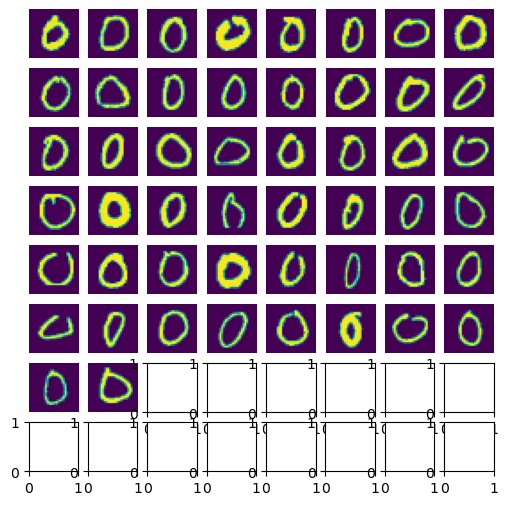

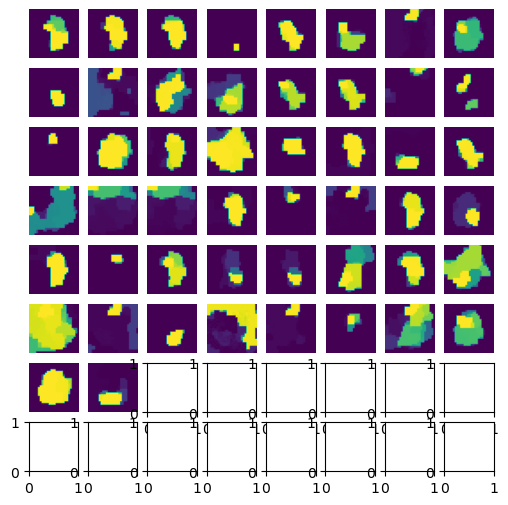

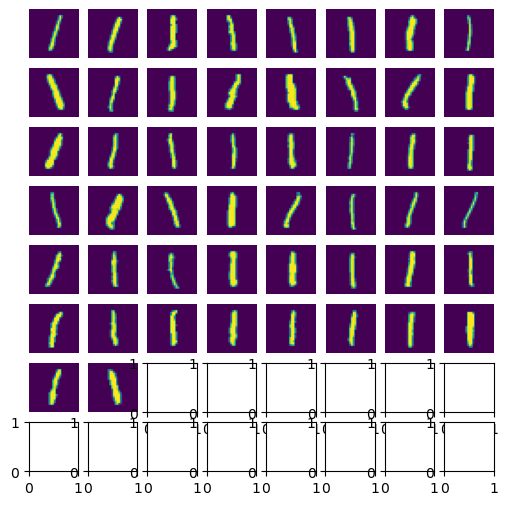

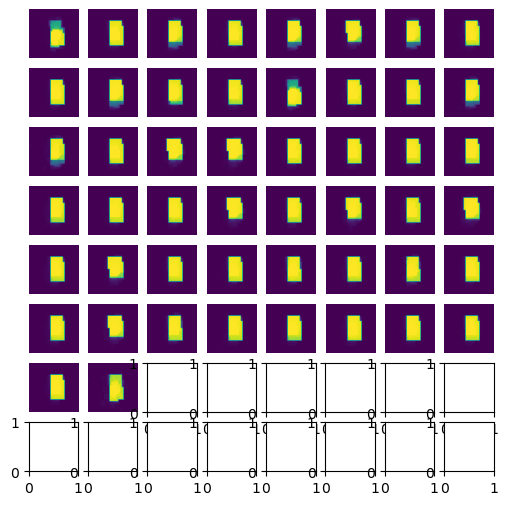

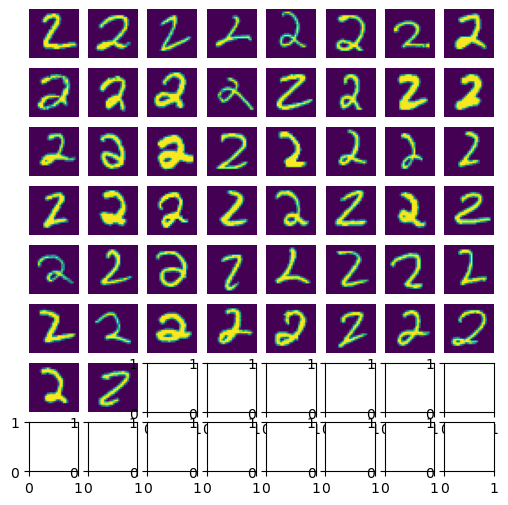

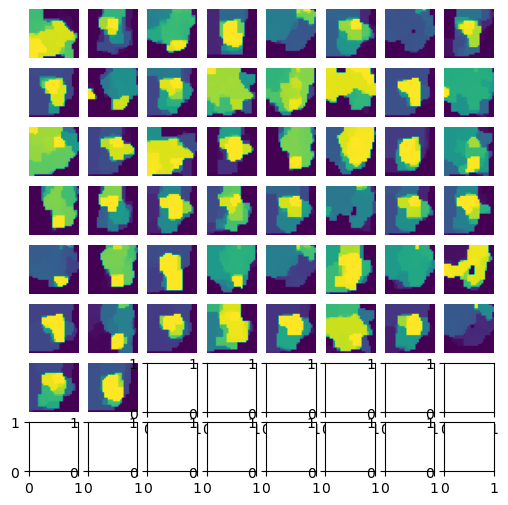

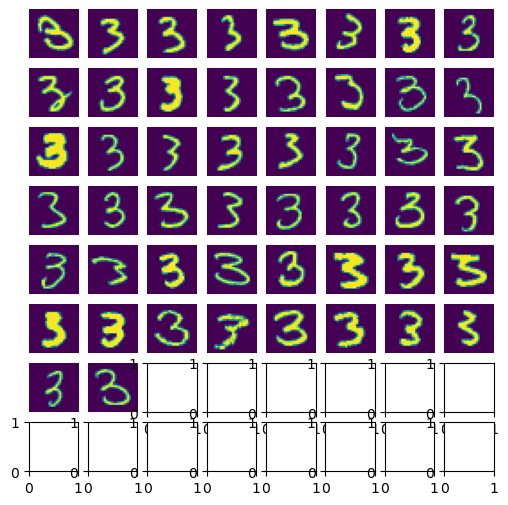

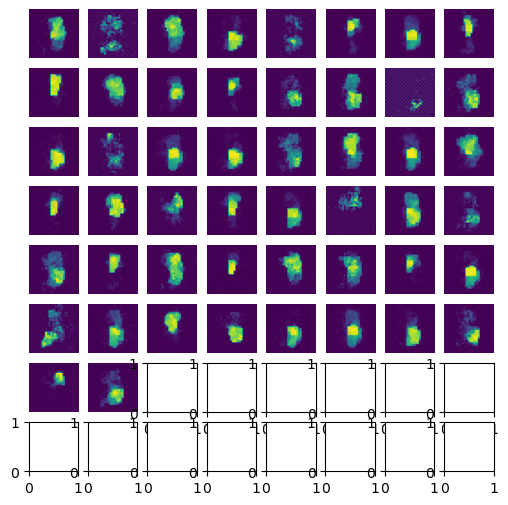

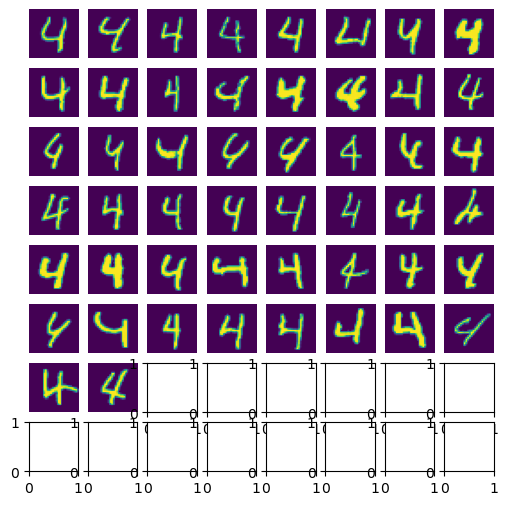

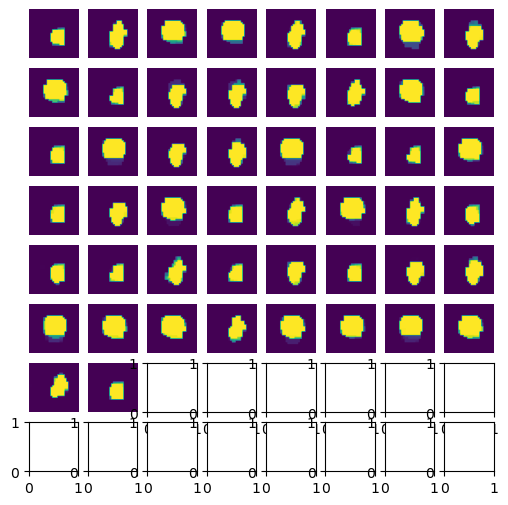

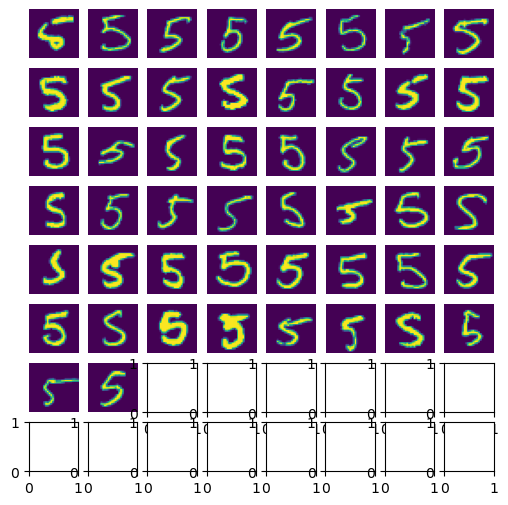

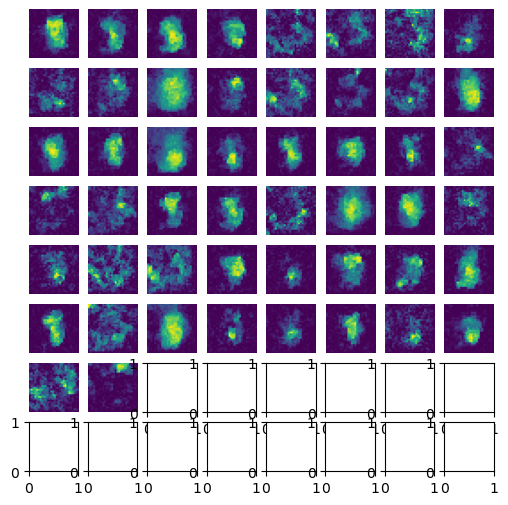

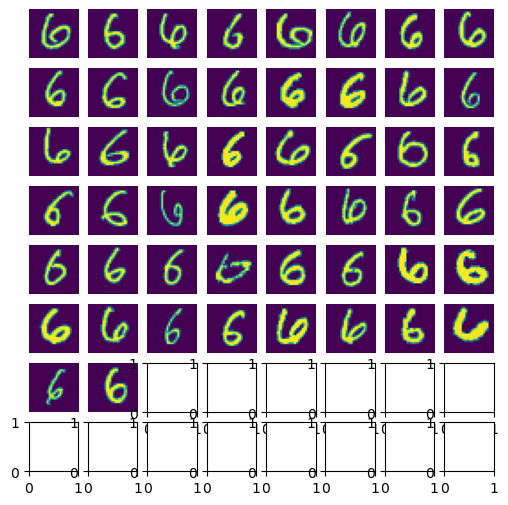

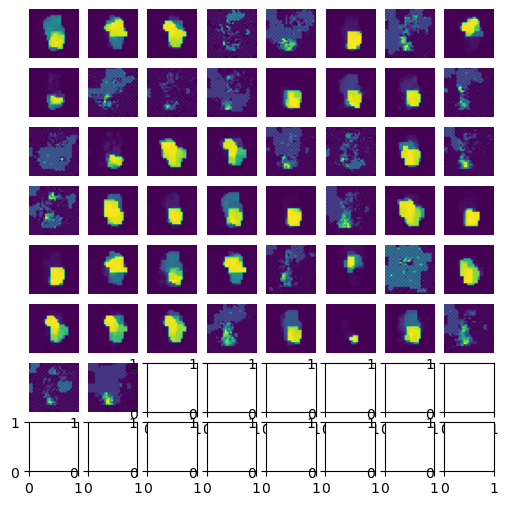

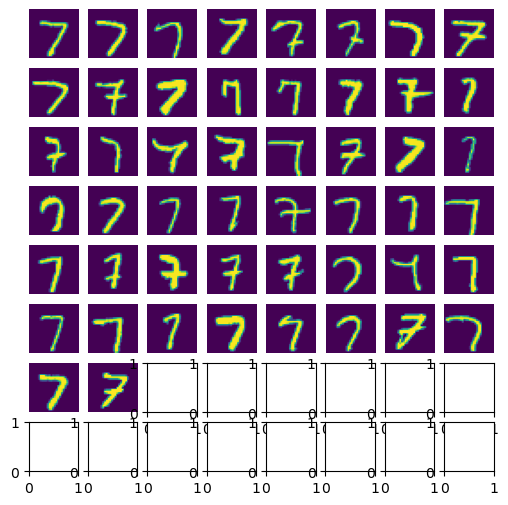

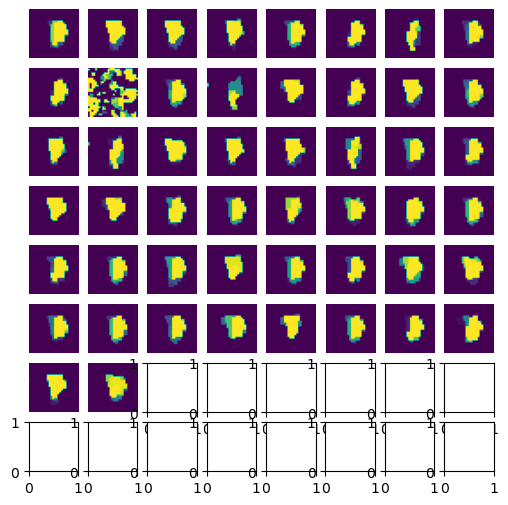

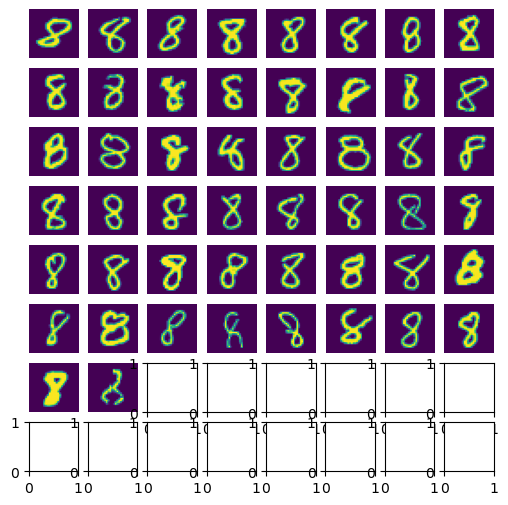

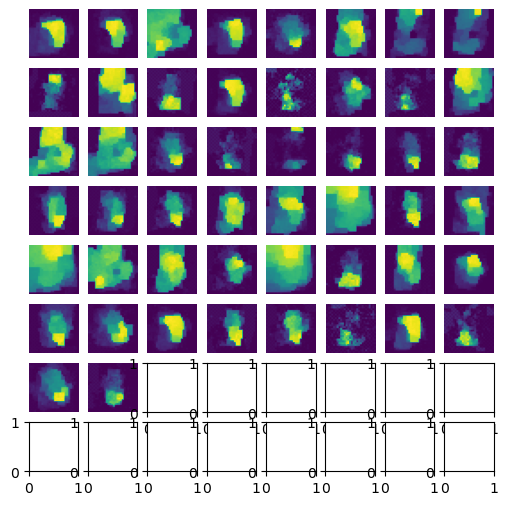

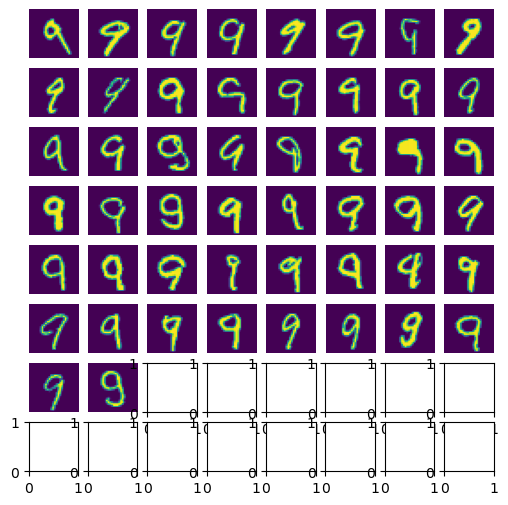

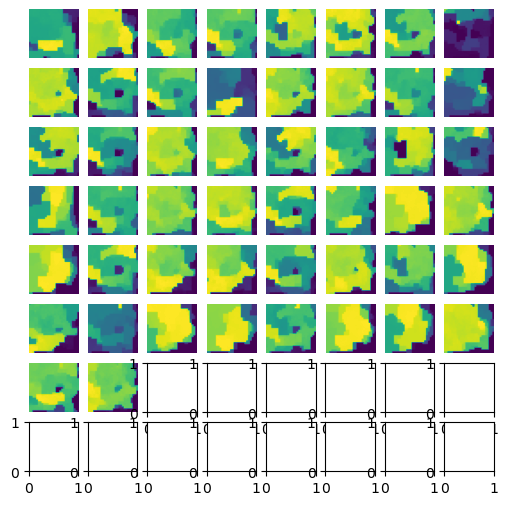

In [4]:
# Uncomment if create one single poisoned data point
# cfg = breaching.get_config(overrides=["case=11_single_mnist", "attack=invertinggradients"])

# Uncomment if create a batch of poisoned data points
cfg = breaching.get_config(overrides=["case=12_batch_mnist", "attack=invertinggradients"])
          
device = torch.device(f'cuda') if torch.cuda.is_available() else torch.device('cpu')
torch.backends.cudnn.benchmark = cfg.case.impl.benchmark
setup = dict(device=device, dtype=getattr(torch, cfg.case.impl.dtype))
setup

cfg.case.data.partition="unique-class"
cfg.case.user.user_idx = 0
cfg.case.model='customnet'

for id in range(10):
    cfg.case.user.user_idx = id
    user, server, model, loss_fn = breaching.cases.construct_case(cfg.case, setup)
    attacker = breaching.attacks.prepare_attack(server.model, server.loss, cfg.attack, setup)
    breaching.utils.overview(server, user, attacker)

    server_payload = server.distribute_payload()
    shared_data, true_user_data = user.compute_local_updates(server_payload)

    print(true_user_data['data'].shape)
    user.plot(true_user_data)

    reconstructed_user_data, stats = attacker.reconstruct([server_payload], [shared_data], {}, dryrun=cfg.dryrun)

    user.plot(reconstructed_user_data)
    torch.save(reconstructed_user_data, 'num_'+str(id)+'_reconstructed_user_data_12_batch.pt')
    np.save('num_'+str(id)+'_reconstructed_user_data_12_batch.npy', reconstructed_user_data['data'].cpu().detach().numpy())

## For single data point:

INFO:breaching.cases.users:Computing user update on user 0 in model mode: eval.
INFO:breaching.attacks.base_attack:Recovered labels [0] through strategy bias-corrected.


Investigating use case single_mnist with server type honest_but_curious.
Using weights from data ordering model
model_arch.1.weight
model_arch.1.bias
model_arch.3.weight
model_arch.3.bias
model_arch.5.weight
model_arch.5.bias
model_arch.7.weight
model_arch.7.bias
Model architecture customnet loaded with 329,927 parameters and 0 buffers.
Overall this is a data ratio of     421:1 for target shape [1, 1, 28, 28] given that num_queries=1.
User (of type UserSingleStep) with settings:
    Number of data points: 1

    Threat model:
    User provides labels: False
    User provides buffers: False
    User provides number of data points: True

    Data:
    Dataset: MNIST
    user: 0
    
        
Server (of type HonestServer) with settings:
    Threat model: Honest-but-curious
    Number of planned queries: 1
    Has external/public data: False

    Model:
        model specification: customnet
        model state: default
        

    Secrets: {}
    
Attacker (of type OptimizationBasedAtta

INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.7506 |  Task loss: 2.2996 | T: 0.00s
INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.1021 |  Task loss: 2.3015 | T: 9.11s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.0988 |  Task loss: 2.3016 | T: 9.01s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.1017 |  Task loss: 2.3016 | T: 9.11s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.0976 |  Task loss: 2.3015 | T: 9.11s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.0985 |  Task loss: 2.3016 | T: 8.68s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.1020 |  Task loss: 2.3015 | T: 9.06s
INFO:breaching.attacks.optimization_based_attack:| It: 7001 | Rec. loss: 0.1004 |  Task loss: 2.3016 | T: 3.39s
INFO:breaching.attacks.optimization_based_attack:| It: 8001 | Rec. loss: 0.1019 |  Task loss: 2.3015 | T: 2

Using weights from data ordering model
model_arch.1.weight
model_arch.1.bias
model_arch.3.weight
model_arch.3.bias
model_arch.5.weight
model_arch.5.bias
model_arch.7.weight
model_arch.7.bias
Model architecture customnet loaded with 329,927 parameters and 0 buffers.
Overall this is a data ratio of     421:1 for target shape [1, 1, 28, 28] given that num_queries=1.
User (of type UserSingleStep) with settings:
    Number of data points: 1

    Threat model:
    User provides labels: False
    User provides buffers: False
    User provides number of data points: True

    Data:
    Dataset: MNIST
    user: 1
    
        
Server (of type HonestServer) with settings:
    Threat model: Honest-but-curious
    Number of planned queries: 1
    Has external/public data: False

    Model:
        model specification: customnet
        model state: default
        

    Secrets: {}
    
Attacker (of type OptimizationBasedAttacker) with settings:
    Hyperparameter Template: invertinggradients

   

INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.5449 |  Task loss: 2.2929 | T: 2.90s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.5444 |  Task loss: 2.2929 | T: 2.88s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.5449 |  Task loss: 2.2928 | T: 2.88s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.5453 |  Task loss: 2.2928 | T: 2.87s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.5446 |  Task loss: 2.2929 | T: 2.90s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.5447 |  Task loss: 2.2928 | T: 2.89s
INFO:breaching.attacks.optimization_based_attack:| It: 7001 | Rec. loss: 0.5445 |  Task loss: 2.2928 | T: 2.93s
INFO:breaching.attacks.optimization_based_attack:| It: 8001 | Rec. loss: 0.5444 |  Task loss: 2.2929 | T: 2.89s
INFO:breaching.attacks.optimization_based_attack:| It: 9001 | Rec. loss: 0.5442 |  Task loss: 2.2929 | T

...

INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.5192 |  Task loss: 2.3099 | T: 2.97s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.5189 |  Task loss: 2.3099 | T: 2.91s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.5180 |  Task loss: 2.3098 | T: 2.91s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.5179 |  Task loss: 2.3098 | T: 2.88s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.5179 |  Task loss: 2.3099 | T: 2.85s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.5182 |  Task loss: 2.3099 | T: 2.90s
INFO:breaching.attacks.optimization_based_attack:| It: 7001 | Rec. loss: 0.5181 |  Task loss: 2.3098 | T: 2.88s
INFO:breaching.attacks.optimization_based_attack:| It: 8001 | Rec. loss: 0.5183 |  Task loss: 2.3099 | T: 2.77s
INFO:breaching.attacks.optimization_based_attack:| It: 9001 | Rec. loss: 0.5178 |  Task loss: 2.3099 | T

Using weights from data ordering model
model_arch.1.weight
model_arch.1.bias
model_arch.3.weight
model_arch.3.bias
model_arch.5.weight
model_arch.5.bias
model_arch.7.weight
model_arch.7.bias
Model architecture customnet loaded with 329,927 parameters and 0 buffers.
Overall this is a data ratio of     421:1 for target shape [1, 1, 28, 28] given that num_queries=1.
User (of type UserSingleStep) with settings:
    Number of data points: 1

    Threat model:
    User provides labels: False
    User provides buffers: False
    User provides number of data points: True

    Data:
    Dataset: MNIST
    user: 8
    
        
Server (of type HonestServer) with settings:
    Threat model: Honest-but-curious
    Number of planned queries: 1
    Has external/public data: False

    Model:
        model specification: customnet
        model state: default
        

    Secrets: {}
    
Attacker (of type OptimizationBasedAttacker) with settings:
    Hyperparameter Template: invertinggradients

   

INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.0585 |  Task loss: 2.2904 | T: 2.89s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.0584 |  Task loss: 2.2903 | T: 2.86s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.0590 |  Task loss: 2.2904 | T: 2.68s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.0655 |  Task loss: 2.2904 | T: 2.58s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.0601 |  Task loss: 2.2904 | T: 2.69s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.0593 |  Task loss: 2.2904 | T: 2.82s
INFO:breaching.attacks.optimization_based_attack:| It: 7001 | Rec. loss: 0.0587 |  Task loss: 2.2903 | T: 2.85s
INFO:breaching.attacks.optimization_based_attack:| It: 8001 | Rec. loss: 0.0651 |  Task loss: 2.2904 | T: 2.91s
INFO:breaching.attacks.optimization_based_attack:| It: 9001 | Rec. loss: 0.0580 |  Task loss: 2.2903 | T

Using weights from data ordering model
model_arch.1.weight
model_arch.1.bias
model_arch.3.weight
model_arch.3.bias
model_arch.5.weight
model_arch.5.bias
model_arch.7.weight
model_arch.7.bias
Model architecture customnet loaded with 329,927 parameters and 0 buffers.
Overall this is a data ratio of     421:1 for target shape [1, 1, 28, 28] given that num_queries=1.
User (of type UserSingleStep) with settings:
    Number of data points: 1

    Threat model:
    User provides labels: False
    User provides buffers: False
    User provides number of data points: True

    Data:
    Dataset: MNIST
    user: 9
    
        
Server (of type HonestServer) with settings:
    Threat model: Honest-but-curious
    Number of planned queries: 1
    Has external/public data: False

    Model:
        model specification: customnet
        model state: default
        

    Secrets: {}
    
Attacker (of type OptimizationBasedAttacker) with settings:
    Hyperparameter Template: invertinggradients

   

INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.6909 |  Task loss: 2.3027 | T: 2.90s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.6891 |  Task loss: 2.3026 | T: 2.92s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.6913 |  Task loss: 2.3025 | T: 2.89s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.6909 |  Task loss: 2.3026 | T: 2.87s
INFO:breaching.attacks.optimization_based_attack:| It: 5001 | Rec. loss: 0.6904 |  Task loss: 2.3026 | T: 2.89s
INFO:breaching.attacks.optimization_based_attack:| It: 6001 | Rec. loss: 0.6883 |  Task loss: 2.3027 | T: 2.88s
INFO:breaching.attacks.optimization_based_attack:| It: 7001 | Rec. loss: 0.6917 |  Task loss: 2.3026 | T: 2.88s
INFO:breaching.attacks.optimization_based_attack:| It: 8001 | Rec. loss: 0.6907 |  Task loss: 2.3025 | T: 2.91s
INFO:breaching.attacks.optimization_based_attack:| It: 9001 | Rec. loss: 0.6928 |  Task loss: 2.3025 | T

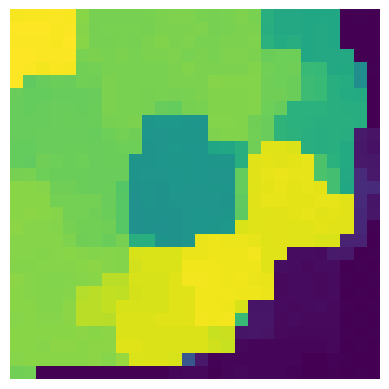

In [4]:
# Uncomment if create one single poisoned data point
cfg = breaching.get_config(overrides=["case=11_single_mnist", "attack=invertinggradients"])
          
device = torch.device(f'cuda') if torch.cuda.is_available() else torch.device('cpu')
torch.backends.cudnn.benchmark = cfg.case.impl.benchmark
setup = dict(device=device, dtype=getattr(torch, cfg.case.impl.dtype))
setup

cfg.case.data.partition="unique-class"
cfg.case.user.user_idx = 0
cfg.case.model='customnet'

for id in range(10):
    cfg.case.user.user_idx = id
    user, server, model, loss_fn = breaching.cases.construct_case(cfg.case, setup)
    attacker = breaching.attacks.prepare_attack(server.model, server.loss, cfg.attack, setup)
    breaching.utils.overview(server, user, attacker)

    server_payload = server.distribute_payload()
    shared_data, true_user_data = user.compute_local_updates(server_payload)

    print(true_user_data['data'].shape)
    user.plot(true_user_data)

    reconstructed_user_data, stats = attacker.reconstruct([server_payload], [shared_data], {}, dryrun=cfg.dryrun)

    user.plot(reconstructed_user_data)
    torch.save(reconstructed_user_data, 'num_'+str(id)+'_reconstructed_user_data_11_single.pt')
    np.save('num_'+str(id)+'_reconstructed_user_data_11_single.npy', reconstructed_user_data['data'].cpu().detach().numpy())


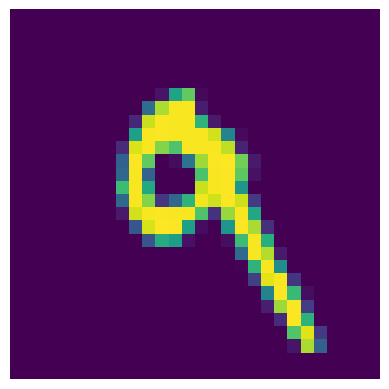

: 

In [7]:
user.plot(true_user_data)

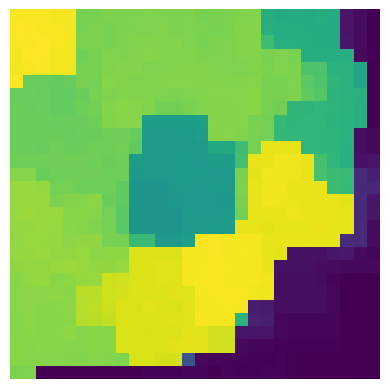

In [6]:
user.plot(reconstructed_user_data)

## Batch size 100

INFO:breaching.cases.users:Computing user update on user 0 in model mode: eval.


Investigating use case single_mnist with server type honest_but_curious.
Using weights from data ordering model
model_arch.1.weight
model_arch.1.bias
model_arch.3.weight
model_arch.3.bias
model_arch.5.weight
model_arch.5.bias
model_arch.7.weight
model_arch.7.bias
Model architecture customnet loaded with 329,927 parameters and 0 buffers.
Overall this is a data ratio of       4:1 for target shape [100, 1, 28, 28] given that num_queries=1.
User (of type UserSingleStep) with settings:
    Number of data points: 100

    Threat model:
    User provides labels: False
    User provides buffers: False
    User provides number of data points: True

    Data:
    Dataset: MNIST
    user: 0
    
        
Server (of type HonestServer) with settings:
    Threat model: Honest-but-curious
    Number of planned queries: 1
    Has external/public data: False

    Model:
        model specification: customnet
        model state: default
        

    Secrets: {}
    
Attacker (of type OptimizationBased

INFO:breaching.attacks.base_attack:Recovered labels [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.5910 |  Task loss: 2.3014 | T: 0.02s
INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.1921 |  Task loss: 2.3015 | T: 5.63s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.1913 |  Task loss: 2.3015 | T: 5.53s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.1912 |  Task loss: 2.3015 | T: 5.51s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.1912 |  Task loss: 2.3015 | T: 5.59s
INFO:breaching.attacks.optimization_based_attack:| It: 50

Using weights from data ordering model
model_arch.1.weight
model_arch.1.bias
model_arch.3.weight
model_arch.3.bias
model_arch.5.weight
model_arch.5.bias
model_arch.7.weight
model_arch.7.bias
Model architecture customnet loaded with 329,927 parameters and 0 buffers.
Overall this is a data ratio of       4:1 for target shape [100, 1, 28, 28] given that num_queries=1.
User (of type UserSingleStep) with settings:
    Number of data points: 100

    Threat model:
    User provides labels: False
    User provides buffers: False
    User provides number of data points: True

    Data:
    Dataset: MNIST
    user: 1
    
        
Server (of type HonestServer) with settings:
    Threat model: Honest-but-curious
    Number of planned queries: 1
    Has external/public data: False

    Model:
        model specification: customnet
        model state: default
        

    Secrets: {}
    
Attacker (of type OptimizationBasedAttacker) with settings:
    Hyperparameter Template: invertinggradients


INFO:breaching.attacks.base_attack:Recovered labels [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.9441 |  Task loss: 2.2925 | T: 0.01s
INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.5605 |  Task loss: 2.2934 | T: 6.24s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.5687 |  Task loss: 2.2934 | T: 6.05s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.5677 |  Task loss: 2.2934 | T: 6.06s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.5677 |  Task loss: 2.2934 | T: 6.07s
INFO:breaching.attacks.optimization_based_attack:| It: 50

...

INFO:breaching.attacks.base_attack:Recovered labels [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.7036 |  Task loss: 2.3106 | T: 0.00s
INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.2844 |  Task loss: 2.3104 | T: 2.88s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.2870 |  Task loss: 2.3104 | T: 2.98s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.2855 |  Task loss: 2.3104 | T: 2.86s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.2834 |  Task loss: 2.3104 | T: 2.94s
INFO:breaching.attacks.optimization_based_attack:| It: 50

Using weights from data ordering model
model_arch.1.weight
model_arch.1.bias
model_arch.3.weight
model_arch.3.bias
model_arch.5.weight
model_arch.5.bias
model_arch.7.weight
model_arch.7.bias
Model architecture customnet loaded with 329,927 parameters and 0 buffers.
Overall this is a data ratio of       4:1 for target shape [100, 1, 28, 28] given that num_queries=1.
User (of type UserSingleStep) with settings:
    Number of data points: 100

    Threat model:
    User provides labels: False
    User provides buffers: False
    User provides number of data points: True

    Data:
    Dataset: MNIST
    user: 8
    
        
Server (of type HonestServer) with settings:
    Threat model: Honest-but-curious
    Number of planned queries: 1
    Has external/public data: False

    Model:
        model specification: customnet
        model state: default
        

    Secrets: {}
    
Attacker (of type OptimizationBasedAttacker) with settings:
    Hyperparameter Template: invertinggradients


INFO:breaching.attacks.base_attack:Recovered labels [8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.5495 |  Task loss: 2.2903 | T: 0.00s
INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.1372 |  Task loss: 2.2904 | T: 2.86s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.1369 |  Task loss: 2.2904 | T: 2.90s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.1344 |  Task loss: 2.2904 | T: 2.93s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.1347 |  Task loss: 2.2904 | T: 2.92s
INFO:breaching.attacks.optimization_based_attack:| It: 50

Using weights from data ordering model
model_arch.1.weight
model_arch.1.bias
model_arch.3.weight
model_arch.3.bias
model_arch.5.weight
model_arch.5.bias
model_arch.7.weight
model_arch.7.bias
Model architecture customnet loaded with 329,927 parameters and 0 buffers.
Overall this is a data ratio of       4:1 for target shape [100, 1, 28, 28] given that num_queries=1.
User (of type UserSingleStep) with settings:
    Number of data points: 100

    Threat model:
    User provides labels: False
    User provides buffers: False
    User provides number of data points: True

    Data:
    Dataset: MNIST
    user: 9
    
        
Server (of type HonestServer) with settings:
    Threat model: Honest-but-curious
    Number of planned queries: 1
    Has external/public data: False

    Model:
        model specification: customnet
        model state: default
        

    Secrets: {}
    
Attacker (of type OptimizationBasedAttacker) with settings:
    Hyperparameter Template: invertinggradients


INFO:breaching.attacks.base_attack:Recovered labels [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9] through strategy bias-corrected.
INFO:breaching.attacks.optimization_based_attack:| It: 1 | Rec. loss: 0.7470 |  Task loss: 2.3039 | T: 0.00s
INFO:breaching.attacks.optimization_based_attack:| It: 1001 | Rec. loss: 0.3642 |  Task loss: 2.3029 | T: 2.96s
INFO:breaching.attacks.optimization_based_attack:| It: 2001 | Rec. loss: 0.3645 |  Task loss: 2.3029 | T: 2.96s
INFO:breaching.attacks.optimization_based_attack:| It: 3001 | Rec. loss: 0.3628 |  Task loss: 2.3029 | T: 2.93s
INFO:breaching.attacks.optimization_based_attack:| It: 4001 | Rec. loss: 0.3626 |  Task loss: 2.3030 | T: 2.95s
INFO:breaching.attacks.optimization_based_attack:| It: 50

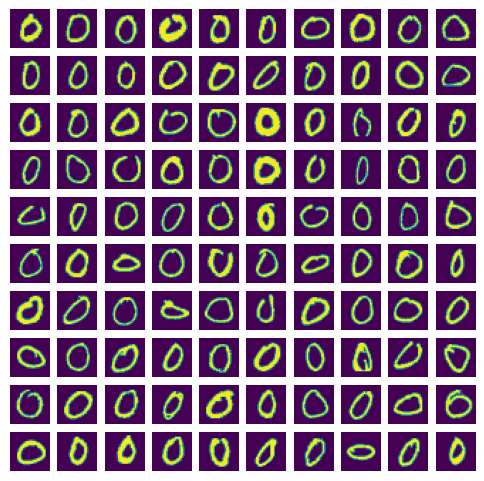

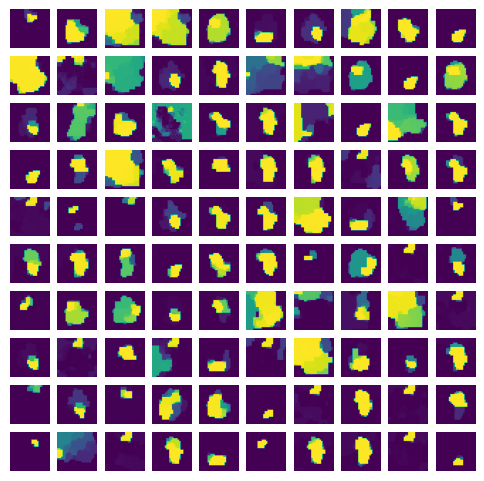

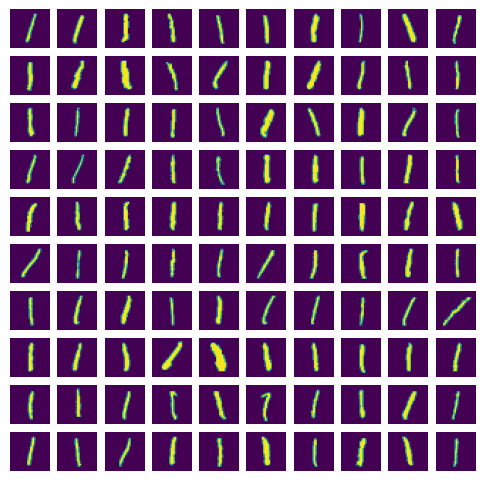

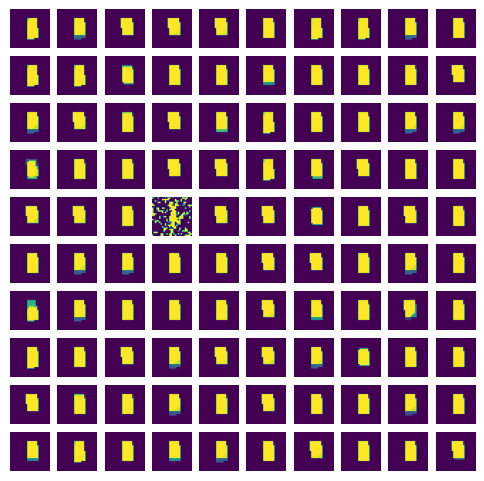

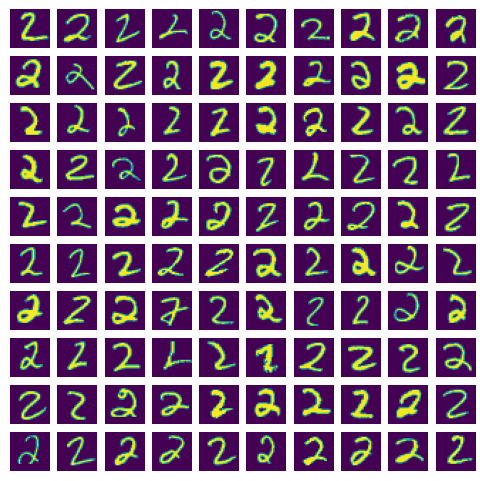

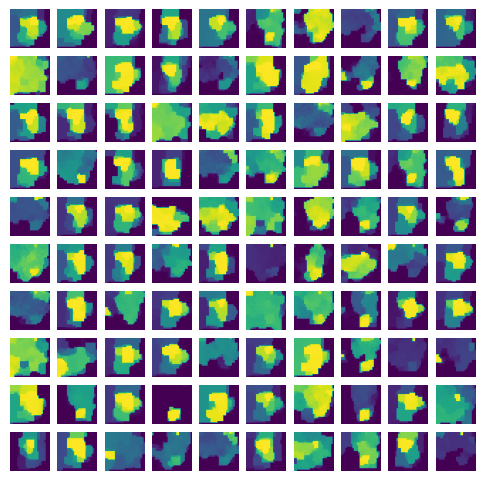

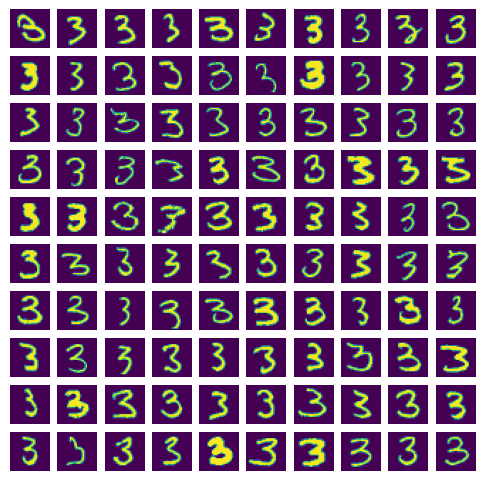

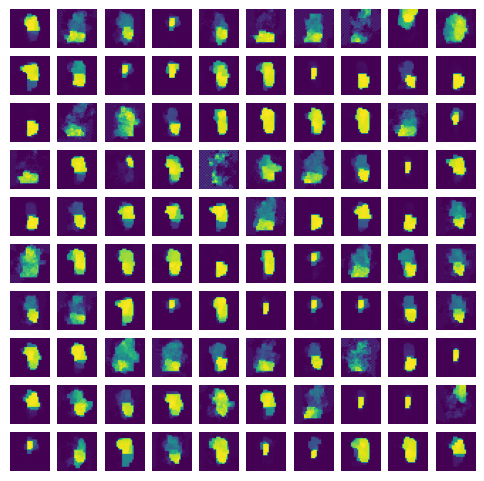

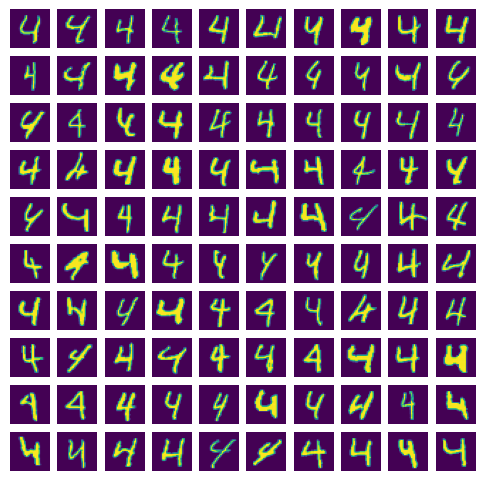

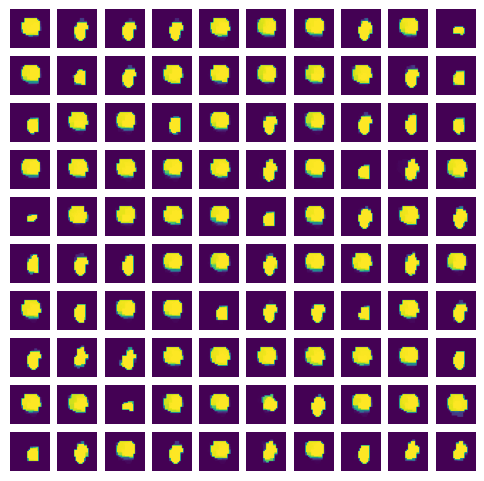

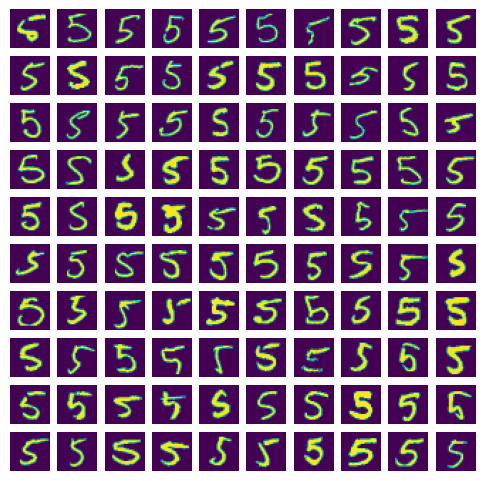

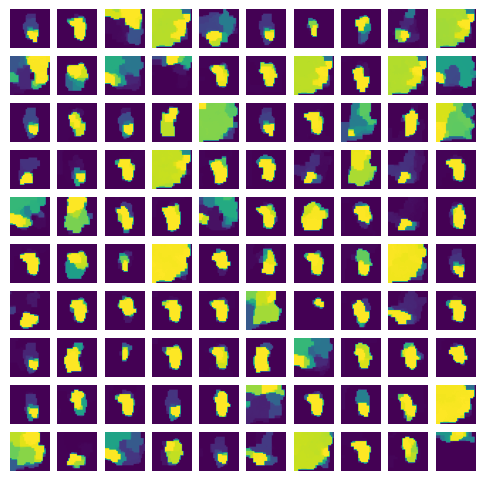

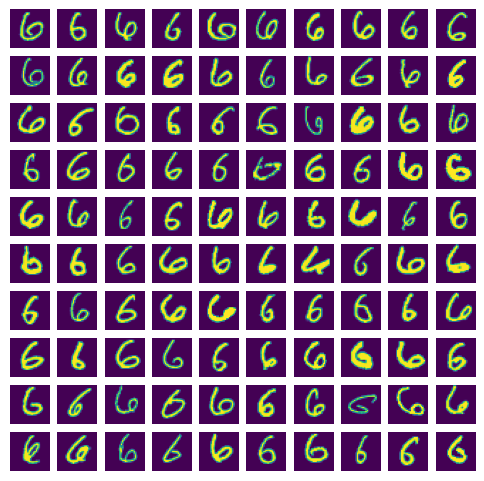

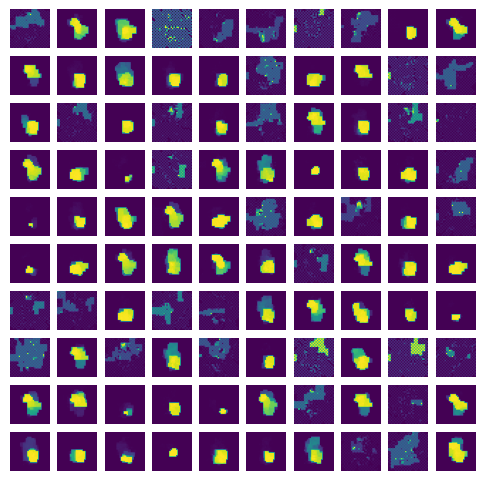

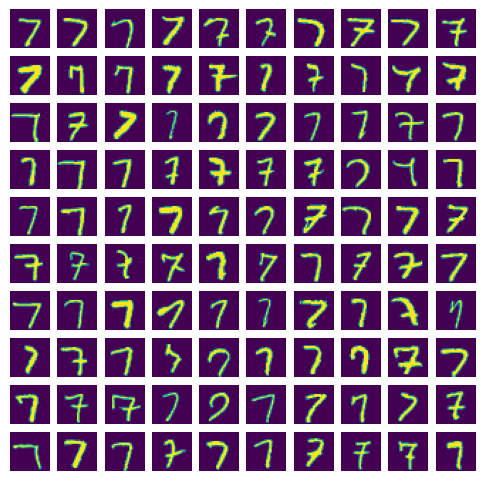

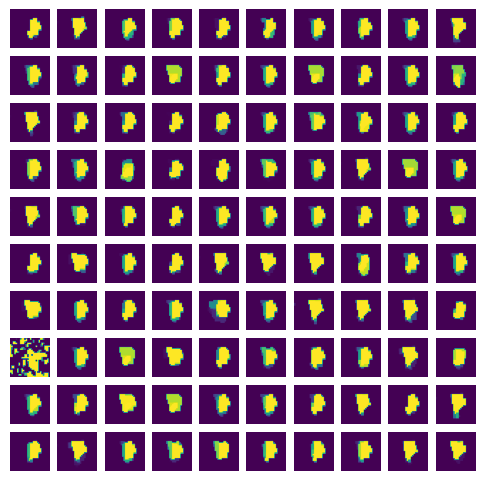

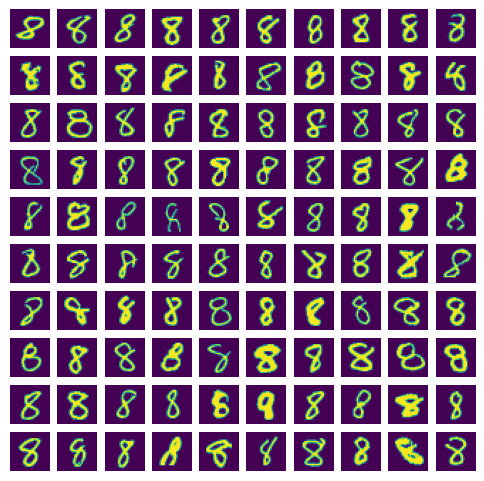

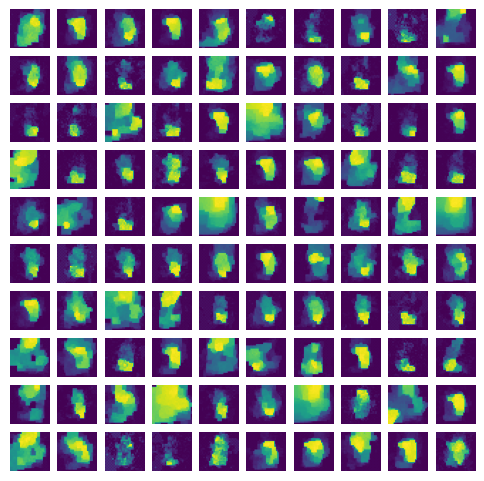

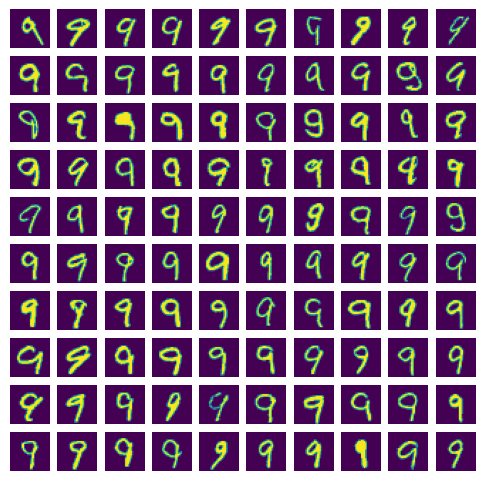

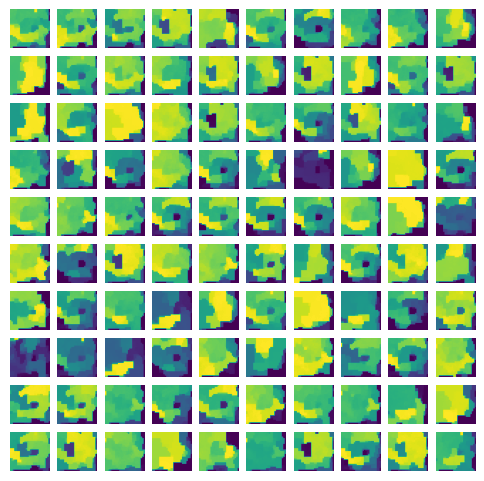

In [6]:
# Uncomment if create a batch of poisoned data points
cfg = breaching.get_config(overrides=["case=12_batch_mnist", "attack=invertinggradients"])
          
device = torch.device(f'cuda') if torch.cuda.is_available() else torch.device('cpu')
torch.backends.cudnn.benchmark = cfg.case.impl.benchmark
setup = dict(device=device, dtype=getattr(torch, cfg.case.impl.dtype))
setup

cfg.case.data.partition="unique-class"
cfg.case.user.user_idx = 0
cfg.case.model='customnet'

for id in range(10):
    cfg.case.user.user_idx = id
    user, server, model, loss_fn = breaching.cases.construct_case(cfg.case, setup)
    attacker = breaching.attacks.prepare_attack(server.model, server.loss, cfg.attack, setup)
    breaching.utils.overview(server, user, attacker)

    server_payload = server.distribute_payload()
    shared_data, true_user_data = user.compute_local_updates(server_payload)

    print(true_user_data['data'].shape)
    user.plot(true_user_data)

    reconstructed_user_data, stats = attacker.reconstruct([server_payload], [shared_data], {}, dryrun=cfg.dryrun)

    user.plot(reconstructed_user_data)
    torch.save(reconstructed_user_data, 'num_'+str(id)+'_reconstructed_user_data_12_batch_100.pt')
    np.save('num_'+str(id)+'_reconstructed_user_data_12_batch_100.npy', reconstructed_user_data['data'].cpu().detach().numpy())